<a href="https://colab.research.google.com/github/maxencebc10/Projet-DATA-groupe-7/blob/main/Copie_de_Am%C3%A9lioration_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
from pyngrok import ngrok
import time
import streamlit as st
import plotly.graph_objects as go

In [ ]:
try:
    df = pd.read_csv('transfers.csv', sep=';', encoding='latin-1')
except:
    df = pd.read_csv('transfers.csv', sep=';', encoding='cp1252')

print(f"Nombre de lignes : {len(df)}")

Nombre de lignes : 79646


In [ ]:
# Création des lignes manquantes

missing_transfers = [
    {
        # NEYMAR (Vers le PSG)
        'player_id': 68290, 'player_name': 'Neymar',
        'transfer_date': '03/08/2017', 'transfer_season': '17/18',
        'from_club_id': 131, 'from_club_name': 'Barcelona',
        'to_club_id': 583, 'to_club_name': 'Paris SG',
        'transfer_fee': 222000000.0, 'market_value_in_eur': 100000000.0
    },
    {
        # CRISTIANO RONALDO (Vers la Juventus)
        'player_id': 8198, 'player_name': 'Cristiano Ronaldo',
        'transfer_date': '10/07/2018', 'transfer_season': '18/19',
        'from_club_id': 418, 'from_club_name': 'Real Madrid',
        'to_club_id': 506, 'to_club_name': 'Juventus',
        'transfer_fee': 117000000.0, 'market_value_in_eur': 100000000.0
    },
    {
        # EDEN HAZARD (Vers le Real Madrid)
        'player_id': 50202, 'player_name': 'Eden Hazard',
        'transfer_date': '01/07/2019', 'transfer_season': '19/20',
        'from_club_id': 631, 'from_club_name': 'Chelsea',
        'to_club_id': 418, 'to_club_name': 'Real Madrid',
        'transfer_fee': 115000000.0, 'market_value_in_eur': 150000000.0
    },
    {
        # GARETH BALE (Vers le Real Madrid)
        'player_id': 39381, 'player_name': 'Gareth Bale',
        'transfer_date': '01/09/2013', 'transfer_season': '13/14',
        'from_club_id': 148, 'from_club_name': 'Tottenham',
        'to_club_id': 418, 'to_club_name': 'Real Madrid',
        'transfer_fee': 101000000.0, 'market_value_in_eur': 65000000.0
    }
]

In [ ]:
# Ajout au dataset

df_add = pd.DataFrame(missing_transfers)
df_complete = pd.concat([df, df_add], ignore_index=True)

print(f"Nombre de lignes après ajout : {len(df_complete)}")

Nombre de lignes après ajout : 79650


In [ ]:
# Sauvegarde du nouveau fichier maître

df_complete.to_csv('transfers_v2.csv', sep=';', index=False)
print("Fichier 'transfers_v2.csv' créé avec l'ajout des 4 transferts les plus coûteux")

Fichier 'transfers_v2.csv' créé avec l'ajout des 4 transferts les plus coûteux


In [ ]:
print("Démarrage de l'agrégation optimisée (Postes + Défense)")

# Fonction anti-erreurs d'encodage
def load_csv_safely(filepath, **kwargs):
    encodings_to_try = ['utf-8', 'utf-8-sig', 'cp1252', 'latin-1']
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(filepath, encoding=enc, **kwargs)
            print(f"'{filepath}' chargé en '{enc}'")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Impossible de lire {filepath} avec les encodages standards.")

# Chargement "sécurisé" des données
df_transfers = load_csv_safely('transfers_v2.csv', sep=';')
df_players = load_csv_safely('players.csv', usecols=['player_id', 'date_of_birth', 'height_in_cm', 'foot', 'position', 'sub_position'])
df_valuations = load_csv_safely('player_valuations.csv', usecols=['player_id', 'date', 'market_value_in_eur'])
df_stats = load_csv_safely('appearances.csv', usecols=['player_id', 'date', 'goals', 'minutes_played', 'assists', 'yellow_cards', 'red_cards'])


# Nettoyage dates & stats
df_stats['date'] = pd.to_datetime(df_stats['date'], errors='coerce')

nb_erreurs = df_stats['date'].isna().sum()
if nb_erreurs > 0:
    print(f"ATTENTION : {nb_erreurs} lignes supprimées dans df_stats à cause de dates invalides")
    df_stats = df_stats.dropna(subset=['date'])

df_transfers['transfer_date'] = pd.to_datetime(df_transfers['transfer_date'], dayfirst=True)
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')
df_valuations['date'] = pd.to_datetime(df_valuations['date'])
# (df_stats['date'] est déjà converti plus haut)

df_transfers = df_transfers.sort_values('transfer_date')
df_valuations = df_valuations.sort_values('date')

print("Construction du profil joueur (Age, Physique, Poste)")
df_final = df_transfers.merge(df_players, on='player_id', how='left')

# Calcul de l'âge des joueurs
df_final['age_at_transfer'] = (df_final['transfer_date'] - df_final['date_of_birth']).dt.days / 365.25

# Valeur marchande
print("Récupération de la cote financière")
df_final = pd.merge_asof(
    df_final, df_valuations,
    left_on='transfer_date', right_on='date', by='player_id',
    direction='backward', suffixes=('', '_hist')
)
df_final['pre_transfer_market_value'] = df_final['market_value_in_eur_hist']
df_final.drop(columns=['date', 'market_value_in_eur_hist'], inplace=True)

# Agrégation des stats (1 an avant)
print("Calcul des stats (Buts, Passes, Cartons, Minutes)")

# Filtre préliminaire
relevant_ids = df_final['player_id'].unique()
df_stats_filtered = df_stats[df_stats['player_id'].isin(relevant_ids)]

# Fusion
temp_merge = df_final[['player_id', 'transfer_date']].merge(df_stats_filtered, on='player_id', how='inner')

# Fenêtre de temps (1 an avant transfert)
mask_window = (temp_merge['date'] < temp_merge['transfer_date']) & \
              (temp_merge['date'] >= temp_merge['transfer_date'] - pd.Timedelta(days=365))
valid_stats = temp_merge[mask_window]

# On ajoute la somme des cartons
stats_agg = valid_stats.groupby(['player_id', 'transfer_date'])[[
    'goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards'
]].sum().reset_index()

# Merge final
df_final = df_final.merge(stats_agg, on=['player_id', 'transfer_date'], how='left')

# Remplissage des NaN (si un joueur n'a pas joué, il a 0 partout)
cols_stats = ['goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards', 'pre_transfer_market_value']
df_final[cols_stats] = df_final[cols_stats].fillna(0)

# 6. Export sécurisé (utf-8-sig)
df_final.to_csv('dataset_training_complet_v2.csv', index=False, encoding='utf-8-sig')
print("\n Fichier 'dataset_training_complet_v2.csv' généré avec succès")
print(df_final[['player_name', 'from_club_name', 'goals', 'yellow_cards', 'minutes_played']].head())

Démarrage de l'agrégation optimisée (Postes + Défense)
'transfers_v2.csv' chargé en 'utf-8'
'players.csv' chargé en 'utf-8'
'player_valuations.csv' chargé en 'utf-8'
'appearances.csv' chargé en 'utf-8'
Construction du profil joueur (Age, Physique, Poste)
Récupération de la cote financière
Calcul des stats (Buts, Passes, Cartons, Minutes)

 Fichier 'dataset_training_complet_v2.csv' généré avec succès
       player_name   from_club_name  goals  yellow_cards  minutes_played
0    Michael Esser   A. Ickern Yth.    0.0           0.0             0.0
1     Sven Ulreich   Lichtenw. Yth.    0.0           0.0             0.0
2      JosÃ© Fonte  FC Penafiel You    0.0           0.0             0.0
3  Antonio Mirante    Castellammare    0.0           0.0             0.0
4       Marco Reus  PTSV Dort. Yth.    0.0           0.0             0.0


In [ ]:
print("Génération du dataset final nettoyé")

# Chargement
df = pd.read_csv('dataset_training_complet_v2.csv')

# Conversion et Nettoyage préliminaire
df['transfer_date'] = pd.to_datetime(df['transfer_date'])
df['year'] = df['transfer_date'].dt.year

# On remplace les NaN par 0 pour pouvoir filtrer
df['transfer_fee'] = df['transfer_fee'].fillna(0)
df['pre_transfer_market_value'] = df['pre_transfer_market_value'].fillna(0)
df['market_value_in_eur'] = df['market_value_in_eur'].fillna(0)

# Calcul de la valeur totale du transfert de chaque joueur
df['total_transfer'] = df['transfer_fee'] + df['market_value_in_eur']

# Filtrage
print(f"Lignes avant nettoyage : {len(df)}")

# On ne garde que les lignes où :
# - Le transfert est payant (> 5000€ pour éviter les micro-sommes symboliques)
# - La valeur marchande est connue (> 0)
mask_clean = (df['transfer_fee'] > 5000) & (df['pre_transfer_market_value'] > 0)
df_clean = df[mask_clean].copy()

print(f"Lignes après nettoyage : {len(df_clean)}")
print("Les transferts gratuits et sans cote ont été supprimés.")


# Calcul des indicateurs

# Puissance Financière (Volume en €)
def calculate_dynamic_power(df, club_col, value_col, new_col_name):
    yearly = df.groupby([club_col, 'year'])[value_col].sum().reset_index()

    # Index complet (pour gérer les années creuses)
    min_y, max_y = yearly['year'].min(), yearly['year'].max()
    all_clubs = yearly[club_col].unique()
    idx = pd.MultiIndex.from_product([all_clubs, range(min_y, max_y + 1)], names=[club_col, 'year'])
    yearly = yearly.set_index([club_col, 'year']).reindex(idx, fill_value=0).reset_index()

    # Moyenne glissante 3 ans (Shift 1 pour ne pas tricher avec l'année en cours)
    yearly[new_col_name] = yearly.groupby(club_col)[value_col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
    )
    return yearly[[club_col, 'year', new_col_name]].fillna(0)

# Biais (Ratio Dépense / Valeur)
def calculate_spending_bias(df, club_col, fee_col, value_col, new_col_name):
    # Somme des Fees et des Valeurs par an
    yearly = df.groupby([club_col, 'year'])[[fee_col, value_col]].sum().reset_index()

    # Index complet
    min_y, max_y = yearly['year'].min(), yearly['year'].max()
    all_clubs = yearly[club_col].unique()
    idx = pd.MultiIndex.from_product([all_clubs, range(min_y, max_y + 1)], names=[club_col, 'year'])
    yearly = yearly.set_index([club_col, 'year']).reindex(idx, fill_value=0).reset_index()

    # Sommes glissantes 3 ans
    roll_fee = yearly.groupby(club_col)[fee_col].transform(
        lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
    )
    roll_val = yearly.groupby(club_col)[value_col].transform(
        lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
    )

    # Calcul du Ratio (+1 pour éviter division par zéro)
    yearly[new_col_name] = (roll_fee + 1) / (roll_val + 1)

    # Si pas d'historique, on met 1.0 (Neutre)
    yearly[new_col_name] = yearly[new_col_name].fillna(1.0)

    return yearly[[club_col, 'year', new_col_name]]

print("Calcul des puissances et biais sur les données nettoyées")

# Calculs
buyer_vol = calculate_dynamic_power(df_clean, 'to_club_name', 'transfer_fee', 'buyer_power_3y')
seller_vol = calculate_dynamic_power(df_clean, 'from_club_name', 'transfer_fee', 'seller_power_3y')

buyer_bias = calculate_spending_bias(df_clean, 'to_club_name', 'transfer_fee', 'pre_transfer_market_value', 'buyer_spending_bias')
seller_bias = calculate_spending_bias(df_clean, 'from_club_name', 'transfer_fee', 'pre_transfer_market_value', 'seller_selling_bias')

# Fusions
df_final = df_clean.merge(buyer_vol, on=['to_club_name', 'year'], how='left')
df_final = df_final.merge(seller_vol, on=['from_club_name', 'year'], how='left')
df_final = df_final.merge(buyer_bias, on=['to_club_name', 'year'], how='left')
df_final = df_final.merge(seller_bias, on=['from_club_name', 'year'], how='left')

# Remplissage final des NaN créés par le merge (nouveaux clubs sans historique)
df_final['buyer_power_3y'] = df_final['buyer_power_3y'].fillna(0)
df_final['seller_power_3y'] = df_final['seller_power_3y'].fillna(0)
df_final['buyer_spending_bias'] = df_final['buyer_spending_bias'].fillna(1.0)
df_final['seller_selling_bias'] = df_final['seller_selling_bias'].fillna(1.0)


# Sauvegarde
output_name = 'dataset_enrichi_final.csv'
df_final.to_csv(output_name, index=False)

print(f"\n Le fichier '{output_name}' ne contient plus que des données fiables.")
print(f"Dimensions finales : {df_final.shape}")
print(df_final[['player_name', 'transfer_fee', 'pre_transfer_market_value', 'buyer_spending_bias']].head())

Génération du dataset final nettoyé
Lignes avant nettoyage : 79650
Lignes après nettoyage : 8882
Les transferts gratuits et sans cote ont été supprimés.
Calcul des puissances et biais sur les données nettoyées

 Le fichier 'dataset_enrichi_final.csv' ne contient plus que des données fiables.
Dimensions finales : (8882, 28)
    player_name  transfer_fee  pre_transfer_market_value  buyer_spending_bias
0   Oleg Ivanov      350000.0                    50000.0                  1.0
1  Scott Carson     1400000.0                   750000.0                  1.0
2    John Ruddy      375000.0                   350000.0                  1.0
3  Thiago Silva     3500000.0                  3500000.0                  1.0
4    Pepe Reina     9800000.0                  4500000.0                  1.0


In [ ]:
print("Démarrage de l'Entraînement (Calculs internes + XGBoost)")

# Chargement et nettoyage
try:
    df = pd.read_csv('dataset_training_complet_v2.csv', encoding='utf-8-sig')
    print("'dataset_training_complet_v2.csv' chargé.")
except FileNotFoundError:
    print("Fichier introuvable.")
    exit()

if 'pre_transfer_market_value' in df.columns:
    if 'market_value_in_eur' in df.columns:
        df = df.drop(columns=['market_value_in_eur'])
    df = df.rename(columns={'pre_transfer_market_value': 'market_value_in_eur'})

df['transfer_fee'] = pd.to_numeric(df['transfer_fee'], errors='coerce')
df['market_value_in_eur'] = pd.to_numeric(df['market_value_in_eur'], errors='coerce')

df = df.dropna(subset=['market_value_in_eur', 'transfer_fee', 'to_club_name', 'from_club_name'])
df = df[(df['market_value_in_eur'] > 100000) & (df['transfer_fee'] > 100000)]

# Calcul des biais pour l'apprentissage
print("Calcul dynamique des biais et puissances pour l'entraînement")

df['ratio_brut'] = df['transfer_fee'] / df['market_value_in_eur']

# On calcule les stats historiques des clubs et on les rattache direct au tableau d'entraînement
stats_acheteurs = df.groupby('to_club_name').agg(
    buyer_spending_bias=('ratio_brut', 'median'),
    buyer_power_3y=('transfer_fee', 'sum')
).reset_index()

stats_vendeurs = df.groupby('from_club_name').agg(
    seller_selling_bias=('ratio_brut', 'median'),
    seller_power_3y=('transfer_fee', 'sum')
).reset_index()

df = df.merge(stats_acheteurs, on='to_club_name', how='left')
df = df.merge(stats_vendeurs, on='from_club_name', how='left')

# Préparation des variables pour XGBoost
df['target_ratio'] = df['ratio_brut'].clip(0.1, 10.0)

# Logarithmes et gestion des valeurs manquantes internes
df['log_market_value'] = np.log1p(df['market_value_in_eur'])
df['log_buyer_power'] = np.log1p(df['buyer_power_3y'].fillna(df['buyer_power_3y'].mean()))
df['log_seller_power'] = np.log1p(df['seller_power_3y'].fillna(df['seller_power_3y'].mean()))

df['buyer_spending_bias'] = df['buyer_spending_bias'].fillna(1.0)
df['seller_selling_bias'] = df['seller_selling_bias'].fillna(1.0)

# Encodage du Poste
le = LabelEncoder()
df['position'] = df['position'].fillna('Missing')
df['position_encoded'] = le.fit_transform(df['position'].astype(str))

# On sauvegarde l'encodeur pour le simulateur
with open('label_encoder_position.pkl', 'wb') as f:
    pickle.dump(le, f)

for col in ['goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards', 'age_at_transfer']:
    df[col] = df.get(col, 0).fillna(0)

# ON CACHE LES BIAIS À L'IA POUR QU'ELLE SE CONCENTRE SUR LE TALENT DU JOUEUR
features = [
    'age_at_transfer', 'log_market_value',
    'log_buyer_power', 'log_seller_power',
    'goals', 'assists', 'minutes_played',
    'yellow_cards', 'red_cards', 'position_encoded'
]

X = df[features]

# Le modèle devine un ratio brut intrinsèque
y = df['target_ratio']

# Poids linéaires absolus (Mbappé pèse 170 Millions de fois plus lourd qu'un joueur à 1€)
weights = df['market_value_in_eur']

print("\nEntraînement de XGBoost")

model = XGBRegressor(
    objective='reg:squarederror', # Modifié pour utiliser MSE
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,       # L'IA a le droit d'isoler des cas rares comme Yamal/Mbappé
    random_state=42
)

model.fit(X, y, sample_weight=weights)

model.save_model("modele_transfert_final.json")
print("Modèle sauvegardé sous 'modele_transfert_final.json'")

Démarrage de l'Entraînement (Calculs internes + XGBoost)
'dataset_training_complet_v2.csv' chargé.
Calcul dynamique des biais et puissances pour l'entraînement

Entraînement de XGBoost
Modèle sauvegardé sous 'modele_transfert_final.json'


Démarrage de l'Analyse Exploratoire (EDA)


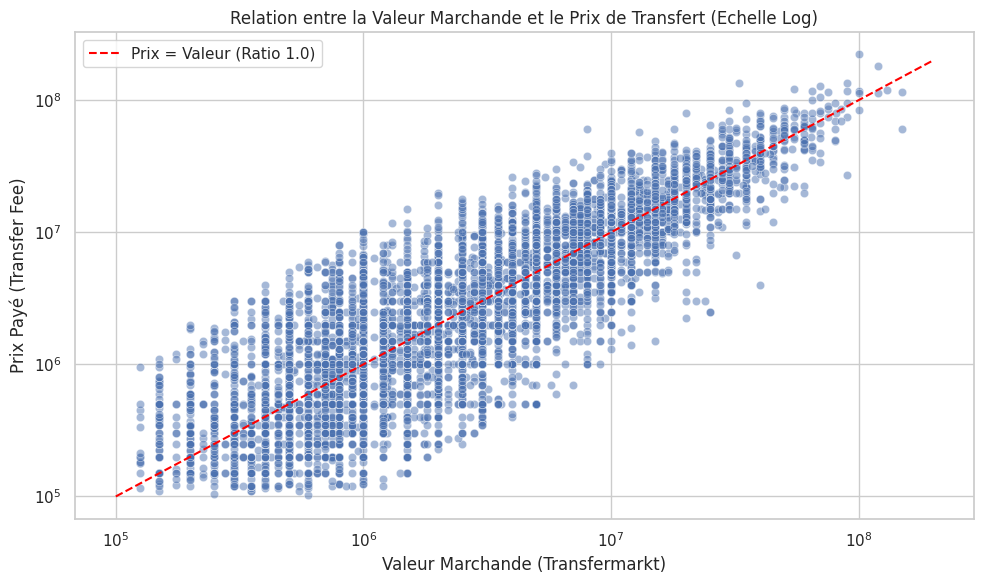

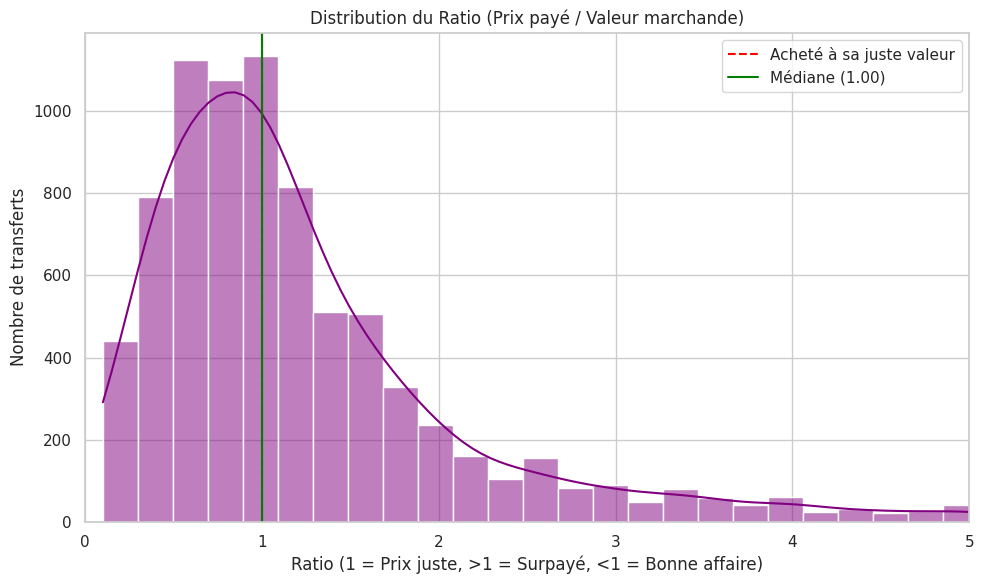

/tmp/ipykernel_16056/2971860373.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_age, x='age_arrondi', y='target_ratio', palette='viridis', showfliers=False)


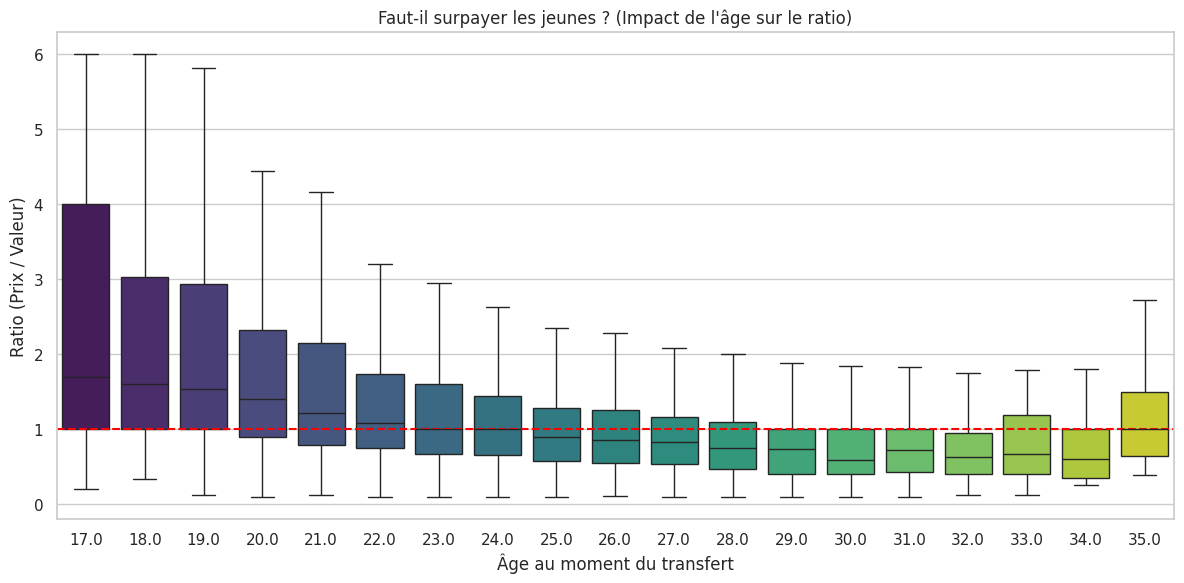

/tmp/ipykernel_16056/2971860373.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='target_ratio', order=order, palette='Set2', showfliers=False)


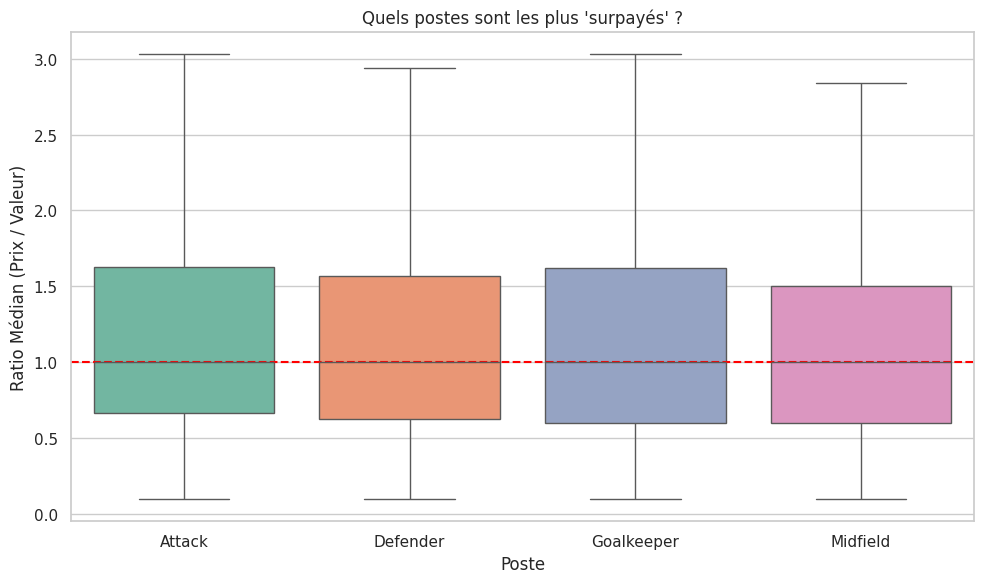

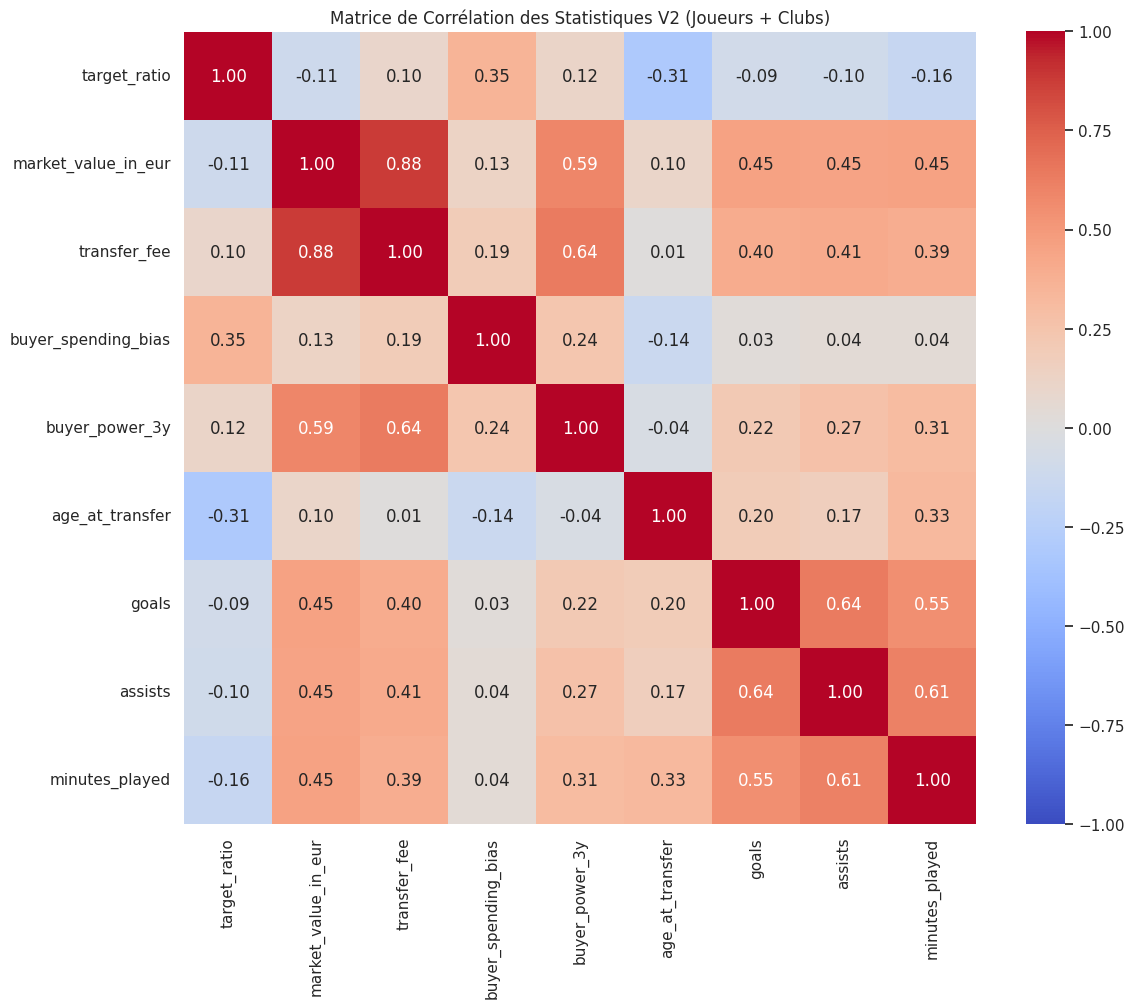


EDA (V2) terminée, les graphiques ont été affichés et sauvegardés (PNG).


In [ ]:
print("Démarrage de l'Analyse Exploratoire (EDA)")

try:
    df = pd.read_csv('dataset_training_complet_v2.csv', encoding='utf-8-sig')
except FileNotFoundError:
    print("Fichier introuvable. Assure-toi d'avoir le bon nom de fichier.")
    exit()

# Renommage de sécurité
if 'pre_transfer_market_value' in df.columns:
    if 'market_value_in_eur' in df.columns:
        df = df.drop(columns=['market_value_in_eur'])
    df = df.rename(columns={'pre_transfer_market_value': 'market_value_in_eur'})

df['transfer_fee'] = pd.to_numeric(df['transfer_fee'], errors='coerce')
df['market_value_in_eur'] = pd.to_numeric(df['market_value_in_eur'], errors='coerce')
df = df.dropna(subset=['market_value_in_eur', 'transfer_fee', 'to_club_name', 'from_club_name'])
df = df[(df['market_value_in_eur'] > 100000) & (df['transfer_fee'] > 100000)]

df['target_ratio'] = df['transfer_fee'] / df['market_value_in_eur']
df = df[(df['target_ratio'] <= 10) & (df['target_ratio'] >= 0.1)]

# Recréation dynamique des Biais pour l'EDA
stats_acheteurs = df.groupby('to_club_name').agg(
    buyer_spending_bias=('target_ratio', 'median'),
    buyer_power_3y=('transfer_fee', 'sum')
).reset_index()

df = df.merge(stats_acheteurs, on='to_club_name', how='left')

# Sécurité sur les stats manquantes
for col in ['goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards', 'age_at_transfer']:
    df[col] = df.get(col, 0).fillna(0)

sns.set_theme(style="whitegrid")

# Graphique 1 : Valeur vs Prix
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='market_value_in_eur', y='transfer_fee', alpha=0.5)
plt.plot([1e5, 2e8], [1e5, 2e8], color='red', linestyle='--', label='Prix = Valeur (Ratio 1.0)')
plt.xscale('log')
plt.yscale('log')
plt.title("Relation entre la Valeur Marchande et le Prix de Transfert (Echelle Log)")
plt.xlabel("Valeur Marchande (Transfermarkt)")
plt.ylabel("Prix Payé (Transfer Fee)")
plt.legend()
plt.tight_layout()
plt.savefig('eda_1_valeur_vs_prix.png')
plt.show()

# Graphique 2 : Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['target_ratio'], bins=50, kde=True, color='purple')
plt.axvline(x=1.0, color='red', linestyle='--', label='Acheté à sa juste valeur')
plt.axvline(x=df['target_ratio'].median(), color='green', linestyle='-', label=f"Médiane ({df['target_ratio'].median():.2f})")
plt.title("Distribution du Ratio (Prix payé / Valeur marchande)")
plt.xlabel("Ratio (1 = Prix juste, >1 = Surpayé, <1 = Bonne affaire)")
plt.ylabel("Nombre de transferts")
plt.legend()
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig('eda_2_distribution_ratio.png')
plt.show()

# Graphique 3 : Âge
plt.figure(figsize=(12, 6))
df['age_arrondi'] = df['age_at_transfer'].round()
df_age = df[(df['age_arrondi'] >= 17) & (df['age_arrondi'] <= 35)]
sns.boxplot(data=df_age, x='age_arrondi', y='target_ratio', palette='viridis', showfliers=False)
plt.axhline(y=1.0, color='red', linestyle='--')
plt.title("Faut-il surpayer les jeunes ? (Impact de l'âge sur le ratio)")
plt.xlabel("Âge au moment du transfert")
plt.ylabel("Ratio (Prix / Valeur)")
plt.tight_layout()
plt.savefig('eda_3_age_vs_ratio.png')
plt.show()

# Graphique 4 : Poste
plt.figure(figsize=(10, 6))
order = df.groupby('position')['target_ratio'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='position', y='target_ratio', order=order, palette='Set2', showfliers=False)
plt.axhline(y=1.0, color='red', linestyle='--')
plt.title("Quels postes sont les plus 'surpayés' ?")
plt.xlabel("Poste")
plt.ylabel("Ratio Médian (Prix / Valeur)")
plt.tight_layout()
plt.savefig('eda_4_poste_vs_ratio.png')
plt.show()

# Graphique 5 : Matrice de corrélation (Améliorée avec les Clubs !)
plt.figure(figsize=(12, 10))
# J'AI AJOUTÉ LES VARIABLES DU CLUB POUR VOIR LEUR IMPACT STATISTIQUE
colonnes_ml = ['target_ratio', 'market_value_in_eur', 'transfer_fee',
               'buyer_spending_bias', 'buyer_power_3y', # Nouveautés cruciales
               'age_at_transfer', 'goals', 'assists', 'minutes_played']

cols_dispo = [c for c in colonnes_ml if c in df.columns]
corr = df[cols_dispo].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matrice de Corrélation des Statistiques V2 (Joueurs + Clubs)")
plt.tight_layout()
plt.savefig('eda_5_correlation.png')
plt.show()

print("\nEDA (V2) terminée, les graphiques ont été affichés et sauvegardés (PNG).")


Analyse de l'importance des variables (Feature Importance)

Classement des variables les plus impactantes (Sur le prix de base) :
- log_market_value : 15.6%
- log_buyer_power : 14.8%
- log_seller_power : 11.8%
- assists : 11.0%
- age_at_transfer : 9.1%
- yellow_cards : 8.5%
- position_encoded : 7.8%
- minutes_played : 7.4%
- goals : 7.0%
- red_cards : 6.9%


/tmp/ipykernel_16056/2500849951.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


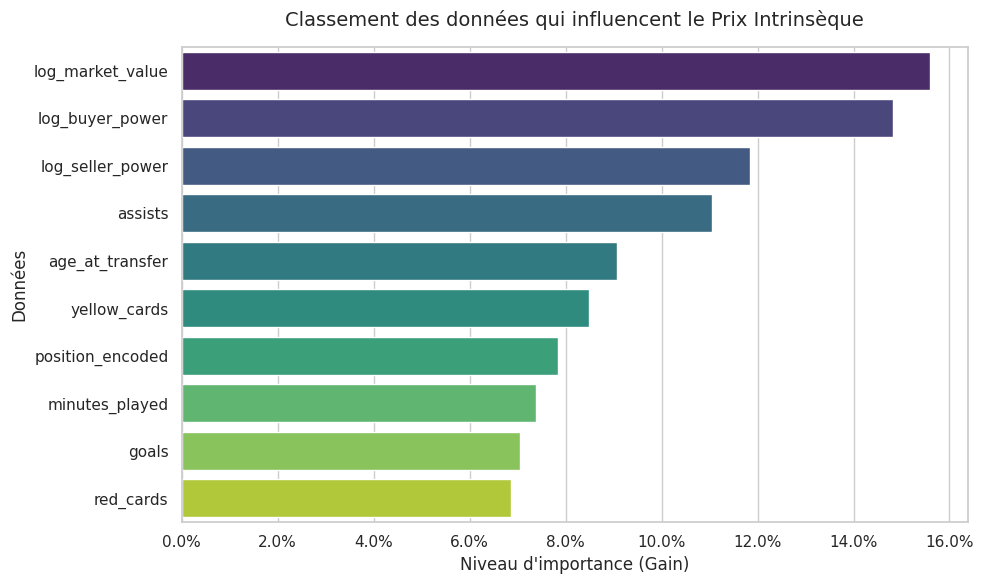


Graphique d'importance sauvegardé sous 'feature_importance.png'.


In [ ]:
print("\nAnalyse de l'importance des variables (Feature Importance)")

# Chargement du modèle qu'on a entraîné
try:
    model = XGBRegressor()
    model.load_model("modele_transfert_final.json")
except:
    print("Modèle introuvable. Lance l'entraînement d'abord")
    exit()

# La liste des 10 variables utilisées dans notre dernière version
features = [
    'age_at_transfer', 'log_market_value',
    'log_buyer_power', 'log_seller_power',
    'goals', 'assists', 'minutes_played',
    'yellow_cards', 'red_cards', 'position_encoded'
]

importances = model.feature_importances_

# Création du tableau
df_importances = pd.DataFrame({
    'Variable': features,
    'Importance': importances
})

# Tri des données
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# Affichage console
print("\nClassement des variables les plus impactantes (Sur le prix de base) :")
for index, row in df_importances.iterrows():
    print(f"- {row['Variable']} : {row['Importance']:.1%}")

# Création du graphique
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_importances,
    x='Importance',
    y='Variable',
    palette='viridis'
)

plt.title("Classement des données qui influencent le Prix Intrinsèque", fontsize=14, pad=15)
plt.xlabel("Niveau d'importance (Gain)", fontsize=12)
plt.ylabel("Données", fontsize=12)

import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nGraphique d'importance sauvegardé sous 'feature_importance.png'.")

In [ ]:
# Configuration des fichiers sources
FILE_TRANSFERS = 'transfers(1).csv'
FILE_PLAYERS = 'players(1).csv'
FILE_APPEARANCES = 'appearances(1).csv'
FILE_GAMES = 'games.csv'

print("\n 1. Analyse Financière des Clubs (2023-2026)")

df_t = pd.read_csv(FILE_TRANSFERS)

# Nettoyage et conversion
df_t['transfer_date'] = pd.to_datetime(df_t['transfer_date'], errors='coerce')
df_t['transfer_fee'] = pd.to_numeric(df_t['transfer_fee'], errors='coerce').fillna(0)
df_t['market_value_in_eur'] = pd.to_numeric(df_t['market_value_in_eur'], errors='coerce').fillna(0)

# FILTRE 1 : TEMPOREL (Les 3 dernières années pour avoir la puissance ACTUELLE)
start_date = pd.Timestamp.now() - pd.DateOffset(years=3)
mask_time = df_t['transfer_date'] > start_date

# FILTRE 2 : QUALITÉ (On ne garde que les transferts payants et avec une valeur connue)
# Cela évite de diviser par zéro et garantit que le biais est calculé sur des vrais achats.
mask_quality = (df_t['transfer_fee'] > 10000) & (df_t['market_value_in_eur'] > 0)

df_clean = df_t[mask_time & mask_quality].copy()
print(f"   -> {len(df_clean)} transferts qualifiés retenus pour l'analyse.")

# Calculs acheteur
buyer_stats = df_clean.groupby('to_club_name').agg({
    'transfer_fee': 'sum',
    'market_value_in_eur': 'sum'
}).reset_index()

# Buyer Power = Moyenne annuelle (Somme / 3 ans)
buyer_stats['buyer_power_3y'] = buyer_stats['transfer_fee'] / 3
# Buyer Bias = Ratio (Combien ils paient pour 1€ de valeur)
buyer_stats['buyer_spending_bias'] = (buyer_stats['transfer_fee'] + 1) / (buyer_stats['market_value_in_eur'] + 1)

# Calculs vendeur
seller_stats = df_clean.groupby('from_club_name').agg({
    'transfer_fee': 'sum',
    'market_value_in_eur': 'sum'
}).reset_index()

seller_stats['seller_power_3y'] = seller_stats['transfer_fee'] / 3
seller_stats['seller_selling_bias'] = (seller_stats['transfer_fee'] + 1) / (seller_stats['market_value_in_eur'] + 1)

# Fusion
master_clubs = pd.merge(
    buyer_stats[['to_club_name', 'buyer_power_3y', 'buyer_spending_bias']],
    seller_stats[['from_club_name', 'seller_power_3y', 'seller_selling_bias']],
    left_on='to_club_name', right_on='from_club_name', how='outer'
)

master_clubs['club_name'] = master_clubs['to_club_name'].fillna(master_clubs['from_club_name'])
# Valeurs par défaut pour les NaNs (Bias neutre = 1.0, Power nul = 0)
master_clubs = master_clubs.fillna({'buyer_power_3y': 0, 'seller_power_3y': 0, 'buyer_spending_bias': 1.0, 'seller_selling_bias': 1.0})

cols_clubs = ['club_name', 'buyer_power_3y', 'buyer_spending_bias', 'seller_power_3y', 'seller_selling_bias']
master_clubs[cols_clubs].to_csv('reference_clubs.csv', index=False)
print(f"'reference_clubs.csv' généré.")

FILE_STATS = 'stats.csv'
FILE_PRIX = 'players.csv'

print("Nettoyage final")

try:
    try:
        df = pd.read_csv(FILE_STATS, sep=None, engine='python')
    except:
        df = pd.read_excel(FILE_STATS)

    print(f"   -> Lignes chargées : {len(df)}")

    # 2. On garde les colonnes importantes
    # Cherche les colonnes qui ressemblent à "Player", "Gls", etc.
    # Parfois FBref met "Player" en colonne 1 ou 2.

    # Renommage intelligent (on cherche les colonnes clés)
    # Adapte les noms à gauche si ton Excel a des noms français (ex: "Joueur")
    rename_map = {
        'Player': 'player_name',
        'Min': 'minutes_played',
        'Gls': 'goals',
        'Ast': 'assists',
        'Age': 'age_actuel',
        'Pos': 'position'
    }
    df = df.rename(columns=rename_map)

    # Nettoyage numérique
    for col in ['minutes_played', 'goals', 'assists']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(',', '')
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # On ajoute les Prix (Kaggle)
    df_prix = pd.read_csv(FILE_PRIX)
    df_prix = df_prix[['name', 'market_value_in_eur']].rename(columns={'name': 'player_name'})

    # Fusion
    final = pd.merge(df, df_prix, on='player_name', how='inner')

    # Sauvegarde
    final.to_csv('reference_joueurs.csv', index=False)
    print("Fichier 'reference_joueurs.csv' prêt avec les stats 24/25")

    # Test
    print("Exemple :")
    print(final[['player_name', 'goals', 'minutes_played']].head(1))

except Exception as e:
    print(f"Erreur : {e}")
    print("Noms de colonnes dans le fichier Excel à vérifier (il faut 'Player', 'Min', 'Gls', 'Ast').")


 1. Analyse Financière des Clubs (2023-2026)
   -> 2446 transferts qualifiés retenus pour l'analyse.
'reference_clubs.csv' généré.
Nettoyage final
   -> Lignes chargées : 2968
Fichier 'reference_joueurs.csv' prêt avec les stats 24/25
Exemple :
  player_name  goals  minutes_played
0  Max Aarons    0.0            86.0


In [ ]:
print("Démarrage du Simulateur Mercato (Mode Hybride)")

try:
    # Chargement du modèle et du traducteur de postes
    model = XGBRegressor()
    model.load_model("modele_transfert_final.json")
    with open('label_encoder_position.pkl', 'rb') as f:
        le = pickle.load(f)

    # Chargement des fichiers de référence 24/25
    ref_clubs = pd.read_csv('reference_clubs.csv').set_index('club_name')
    ref_joueurs = pd.read_csv('reference_joueurs.csv')

    # Harmonisation des noms de colonnes si besoin
    if 'market_value_in_eur' in ref_joueurs.columns:
        ref_joueurs = ref_joueurs.rename(columns={'market_value_in_eur': 'derniere_valeur_connue'})

    # Sécurité pour les stats (remplace par 0 si la colonne manque)
    for col in ['goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards']:
        if col not in ref_joueurs.columns:
            ref_joueurs[col] = 0

    ref_joueurs = ref_joueurs.set_index('player_name')
    print("Modèle et Fichiers 'reference_joueurs' / 'reference_clubs' chargés")

except Exception as e:
    print(f"ERREUR DE CHARGEMENT : {e}")

# Fonction de simulation
def simuler_transfert(joueur_nom, club_acheteur_nom, club_vendeur_nom=None):
    print("\n" + "━"*60)
    print(f"SIMULATION : {joueur_nom} -> {club_acheteur_nom}")
    print("━"*60)

    # 1. Recherche du joueur
    matchs = ref_joueurs.index[ref_joueurs.index.str.contains(joueur_nom, case=False, na=False)]
    if len(matchs) == 0:
        print(f"'{joueur_nom}' introuvable dans 'reference_joueurs.csv'.")
        return

    joueur_id = matchs[0]
    joueur = ref_joueurs.loc[joueur_id]
    if isinstance(joueur, pd.DataFrame): joueur = joueur.iloc[0] # Si doublons, on prend le premier
    valeur = joueur.get('derniere_valeur_connue', 0)

    # 2. Recherche du club acheteur
    matchs_ach = ref_clubs.index[ref_clubs.index.str.contains(club_acheteur_nom, case=False, na=False)]
    if len(matchs_ach) > 0:
        vrai_nom_ach = matchs_ach[0]
        club_ach = ref_clubs.loc[vrai_nom_ach]
        power = club_ach.get('buyer_power_3y', ref_clubs['buyer_power_3y'].mean())
        bias_achat = club_ach.get('buyer_spending_bias', 1.0)
        print(f"Acheteur trouvé : {vrai_nom_ach} (Biais : x{bias_achat:.2f} | Puissance: {power:,.0f} €)")
    else:
        power = ref_clubs['buyer_power_3y'].mean()
        bias_achat = 1.0
        print(f"Acheteur '{club_acheteur_nom}' inconnu. Puissance et Biais moyens appliqués.")

    # 3. Recherche du club vendeur (optionnel)
    if club_vendeur_nom:
        matchs_vend = ref_clubs.index[ref_clubs.index.str.contains(club_vendeur_nom, case=False, na=False)]
        if len(matchs_vend) > 0:
            club_vend = ref_clubs.loc[matchs_vend[0]]
            seller_power = club_vend.get('seller_power_3y', ref_clubs['seller_power_3y'].mean())
            bias_vente = club_vend.get('seller_selling_bias', 1.0)
            print(f"Vendeur trouvé  : {matchs_vend[0]} (Biais : x{bias_vente:.2f})")
        else:
            seller_power = ref_clubs['seller_power_3y'].mean()
            bias_vente = 1.0
    else:
        seller_power = ref_clubs['seller_power_3y'].mean()
        bias_vente = 1.0

    # 4. Préparation des données (Pour XGBoost - SANS LES BIAIS)
    try:
        pos_encoded = le.transform([str(joueur['position'])])[0]
    except:
        pos_encoded = 0 # Sécurité si le poste est inconnu

    # ON CACHE LES BIAIS AU MODELE (Seulement 10 variables)
    input_data = pd.DataFrame({
        'age_at_transfer': [joueur['age_actuel']],
        'log_market_value': [np.log1p(valeur)],
        'log_buyer_power': [np.log1p(power)],
        'log_seller_power': [np.log1p(seller_power)],
        'goals': [joueur['goals']],
        'assists': [joueur['assists']],
        'minutes_played': [joueur['minutes_played']],
        'yellow_cards': [joueur['yellow_cards']],
        'red_cards': [joueur['red_cards']],
        'position_encoded': [pos_encoded]
    })

    # PRÉDICTION HYBRIDE (IA Pure -> Ratio)
    ratio_ia = float(model.predict(input_data)[0])

    # Règle 1 : si > 80M€
    if valeur >= 80000000 and ratio_ia < 0.85:
        ratio_ia = 0.85

    # Règle 2 : Joueurs de 20 à 28 ans valant entre 20M€ et 80M€
    # Un joueur dans la force de l'âge ne part pas à -50%. On corrige l'inflation 24/25.
    elif 20 <= joueur['age_actuel'] <= 28 and 20000000 <= valeur < 80000000:
        if ratio_ia < 0.90:
            # On remonte doucement le ratio pour qu'il s'approche de 1.0
            ratio_ia = max(0.90, ratio_ia * 1.5)

    # Règle 3 : âge += 30 ans
    # On ne fait rien ! Le modèle a raison de les décoter.

    prix_ia_brut = max(0, valeur * ratio_ia) # Prix objectif calculé

    prix_estime = prix_ia_brut * bias_achat
    ecart = prix_estime - valeur

    print(f"\n Profil : {joueur_id} ({joueur['age_actuel']:.1f} ans) | Valeur TM : {valeur:,.0f} €")
    print(f"Ratio marché intrinsèque (IA) : x{ratio_ia:.2f} -> Prix neutre : {prix_ia_brut:,.0f} €")
    print("\n" + "="*50)
    print(f"PRIX DE TRANSFERT FINAL ({club_acheteur_nom}) : {prix_estime:,.0f} € (Biais club x{bias_achat:.2f})")
    print("=" * 50)

    if ecart > 0:
        print(f"Surcote : +{ecart:,.0f} € par rapport à la valeur Transfermarkt")
    else:
        print(f"Décote : {ecart:,.0f} € par rapport à la valeur Transfermarkt")

Démarrage du Simulateur Mercato (Mode Hybride)
Modèle et Fichiers 'reference_joueurs' / 'reference_clubs' chargés


In [ ]:
simuler_transfert("Vitinha", "Chelsea")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIMULATION : Vitinha -> Chelsea
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Acheteur trouvé : Chelsea (Biais : x1.50 | Puissance: 268,136,667 €)

 Profil : Vitinha (24.0 ans) | Valeur TM : 60,000,000 €
Ratio marché intrinsèque (IA) : x0.90 -> Prix neutre : 54,000,000 €

PRIX DE TRANSFERT FINAL (Chelsea) : 81,268,737 € (Biais club x1.50)
Surcote : +21,268,737 € par rapport à la valeur Transfermarkt


In [ ]:
simuler_transfert("Lamine Yamal", "Chelsea")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIMULATION : Lamine Yamal -> Chelsea
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Acheteur trouvé : Chelsea (Biais : x1.50 | Puissance: 268,136,667 €)

 Profil : Lamine Yamal (17.0 ans) | Valeur TM : 180,000,000 €
Ratio marché intrinsèque (IA) : x1.13 -> Prix neutre : 202,601,602 €

PRIX DE TRANSFERT FINAL (Chelsea) : 304,910,673 € (Biais club x1.50)
Surcote : +124,910,673 € par rapport à la valeur Transfermarkt


In [ ]:
simuler_transfert("Vitinha", "Marseille")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIMULATION : Vitinha -> Marseille
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Acheteur trouvé : Marseille (Biais : x0.83 | Puissance: 68,533,333 €)

 Profil : Vitinha (24.0 ans) | Valeur TM : 60,000,000 €
Ratio marché intrinsèque (IA) : x1.07 -> Prix neutre : 64,173,245 €

PRIX DE TRANSFERT FINAL (Marseille) : 53,030,624 € (Biais club x0.83)
Décote : -6,969,376 € par rapport à la valeur Transfermarkt


In [ ]:
simuler_transfert("Lamine Yamal", "Real Madrid", "FC Barcelona")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIMULATION : Lamine Yamal -> Real Madrid
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Acheteur trouvé : Real Madrid (Biais : x0.88 | Puissance: 62,333,333 €)

 Profil : Lamine Yamal (17.0 ans) | Valeur TM : 180,000,000 €
Ratio marché intrinsèque (IA) : x1.48 -> Prix neutre : 266,305,547 €

PRIX DE TRANSFERT FINAL (Real Madrid) : 234,901,591 € (Biais club x0.88)
Surcote : +54,901,591 € par rapport à la valeur Transfermarkt


In [ ]:
!pip install -q streamlit xgboost

In [ ]:
%%writefile app.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
from pyngrok import ngrok
import time
import streamlit as st
import plotly.graph_objects as go

# CONFIGURATION DE LA PAGE
st.set_page_config(page_title="Simulateur Mercato IA", page_icon="⚽", layout="wide")

@st.cache_resource
def load_ai():
    model = XGBRegressor()
    model.load_model("modele_transfert_final.json")
    with open('label_encoder_position.pkl', 'rb') as f:
        le = pickle.load(f)
    return model, le

@st.cache_data
def load_data():
    ref_clubs = pd.read_csv('reference_clubs.csv').set_index('club_name')
    ref_joueurs = pd.read_csv('reference_joueurs.csv')
    if 'market_value_in_eur' in ref_joueurs.columns:
        ref_joueurs = ref_joueurs.rename(columns={'market_value_in_eur': 'derniere_valeur_connue'})
    for col in ['goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards']:
        if col not in ref_joueurs.columns:
            ref_joueurs[col] = 0
    ref_joueurs = ref_joueurs.set_index('player_name')
    return ref_joueurs, ref_clubs

model, le = load_ai()
ref_joueurs, ref_clubs = load_data()

# HEADER ET TITRE
st.title("Simulateur de Mercato 24/25")
st.markdown("*Analyse les stats, observe la puissance du club, et découvre le vrai prix du marché !*")

# SIDEBAR (Menu à gauche)
st.sidebar.header("Paramètres du Transfert")
joueurs_dispos = sorted(ref_joueurs.index.tolist())
clubs_dispos = sorted(ref_clubs.index.tolist())

joueur_selectionne = st.sidebar.selectbox("Joueur ciblé", joueurs_dispos)
club_acheteur_selectionne = st.sidebar.selectbox("Club Acheteur", clubs_dispos, index=clubs_dispos.index('Chelsea FC') if 'Chelsea FC' in clubs_dispos else 0)
club_vendeur_selectionne = st.sidebar.selectbox("Club Vendeur (Optionnel)", ["Aucun"] + clubs_dispos)

lancer = st.sidebar.button("🔮 Lancer la Simulation", type="primary", use_container_width=True)

# --- RECUPERATION DES INFOS ---
joueur = ref_joueurs.loc[joueur_selectionne]
if isinstance(joueur, pd.DataFrame): joueur = joueur.iloc[0]
valeur = joueur.get('derniere_valeur_connue', 0)
minutes = joueur.get('minutes_played', 0)
buts = joueur.get('goals', 0)
passes = joueur.get('assists', 0)
jaunes = joueur.get('yellow_cards', 0)
rouges = joueur.get('red_cards', 0)
age = joueur.get('age_actuel', 25)

club_ach = ref_clubs.loc[club_acheteur_selectionne]
power = club_ach.get('buyer_power_3y', ref_clubs['buyer_power_3y'].mean())
bias_achat = club_ach.get('buyer_spending_bias', 1.0)

# AFFICHAGE EN DIRECT
col1, col2 = st.columns(2)

with col1:
    st.markdown(f"### 🏃 Profil : {joueur_selectionne}")
    st.info(f"**Âge :** {age:.1f} ans | **Valeur TM :** {valeur:,.0f} €")

    # CREATION DU RADAR CHART (Notes sur 100)
    # On normalise les stats pour faire un beau graphique :
    note_finition = min(100, (buts / 25) * 100) # 25 buts = note de 100
    note_creativite = min(100, (passes / 15) * 100) # 15 passes = note de 100
    note_endurance = min(100, (minutes / 3500) * 100) # 3500 min = note de 100
    note_discipline = max(0, 100 - (jaunes * 5 + rouges * 15)) # Moins on a de cartons, plus la note est haute
    note_potentiel = max(0, 100 - max(0, age - 20) * 4) # Un joueur de 20 ans a 100, ça baisse avec l'âge

    categories = ['Finition (Buts)', 'Créativité (Passes)', 'Endurance (Minutes)', 'Discipline', 'Potentiel (Âge)']
    notes = [note_finition, note_creativite, note_endurance, note_discipline, note_potentiel]

    # On boucle la liste pour fermer le dessin du radar
    fig = go.Figure(data=go.Scatterpolar(
        r=notes + [notes[0]],
        theta=categories + [categories[0]],
        fill='toself',
        line_color='#00d4ff', # Bleu électrique très "tech"
        fillcolor='rgba(0, 212, 255, 0.4)',
        name='Stats'
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 100], showticklabels=False),
            bgcolor='rgba(0,0,0,0)' # Fond transparent
        ),
        showlegend=False,
        margin=dict(l=40, r=40, t=20, b=20),
        height=350,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)'
    )

    # Affichage du radar dans l'interface
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.markdown(f"### 🏟️ Acheteur : {club_acheteur_selectionne}")
    st.warning(f"**Puissance Financière (3 ans) :** {power:,.0f} €")

    label_biais = "Pigeon" if bias_achat > 1.2 else "Négociateur" if bias_achat < 0.9 else "Normal"
    st.metric("Tendance à surpayer (Biais)", f"x{bias_achat:.2f}", label_biais, delta_color="inverse")

    # Rappel des vraies stats en texte juste en dessous
    st.markdown("#### 📊 Statistiques brutes (Saison)")
    c1, c2, c3 = st.columns(3)
    c1.metric("⚽ Buts", int(buts))
    c2.metric("👟 Passes D.", int(passes))
    c3.metric("⏱️ Minutes", int(minutes))

st.divider()

# --- MOTEUR DE SIMULATION ---
if lancer:
    with st.spinner("Le modèle fouille dans ses archives"):
        if club_vendeur_selectionne != "Aucun":
            club_vend = ref_clubs.loc[club_vendeur_selectionne]
            seller_power = club_vend.get('seller_power_3y', ref_clubs['seller_power_3y'].mean())
        else:
            seller_power = ref_clubs['seller_power_3y'].mean()

        try: pos_encoded = le.transform([str(joueur['position'])])[0]
        except: pos_encoded = 0

        input_data = pd.DataFrame({
            'age_at_transfer': [age],
            'log_market_value': [np.log1p(valeur)],
            'log_buyer_power': [np.log1p(power)],
            'log_seller_power': [np.log1p(seller_power)],
            'goals': [buts],
            'assists': [passes],
            'minutes_played': [minutes],
            'yellow_cards': [jaunes],
            'red_cards': [rouges],
            'position_encoded': [pos_encoded]
        })

        ratio_ia = float(model.predict(input_data)[0])

        # Règles Métier
        if valeur >= 80000000 and ratio_ia < 0.85: ratio_ia = 0.85
        elif 20 <= age <= 28 and 20000000 <= valeur < 80000000:
            if ratio_ia < 0.85 and (minutes > 2000 or buts > 8):
                ratio_ia = max(0.85, ratio_ia + 0.30)

        prix_ia_brut = max(0, valeur * ratio_ia)
        prix_estime = prix_ia_brut * bias_achat

        st.balloons()
        st.success("✅ Accord trouvé ! Voici les détails de l'estimation :")

        res_col1, res_col2 = st.columns(2)
        with res_col1:
            st.markdown("#### Évaluation Objective (IA pure)")
            st.metric("Prix Juste", f"{prix_ia_brut:,.0f} €", f"Ratio Joueur: x{ratio_ia:.2f}", delta_color="off")

        with res_col2:
            st.markdown("#### Prix Final Négocié")
            ecart = prix_estime - valeur
            st.metric("PRIX DU TRANSFERT", f"{prix_estime:,.0f} €", f"{ecart:,.0f} € vs Transfermarkt", delta_color="normal" if ecart > 0 else "inverse")

        st.info(f"**Le résumé du transfert :** Le profil de **{joueur_selectionne}** mérite un multiplicateur de x{ratio_ia:.2f} par rapport à sa valeur théorique. Mais quand **{club_acheteur_selectionne}** arrive à la table des négociations avec sa réputation (Biais x{bias_achat:.2f}), le prix se fixe finalement autour de **{prix_estime:,.0f} €**.")

Overwriting app.py


In [ ]:
!pip install pyngrok -q
from pyngrok.exception import PyngrokNgrokHTTPError

# IDENTIFICATION NGROK
NGROK_TOKEN = "38wdKaoJ121nrbFatMBGGi0G2aD_84ABdngXK3Gh5pSsd3AGm"
ngrok.set_auth_token(NGROK_TOKEN)

# Nettoyage et Lancement
ngrok.kill()
get_ipython().system_raw('streamlit run app.py &')
time.sleep(3)

# Création du tunnel sécurisé
try:
    public_url = ngrok.connect(8501)
    print("\n" + "="*50)
    print("SITE STREAMLIT EST PRÊT ET SÉCURISÉ")
    print("Clique sur ce lien pour l'ouvrir :")
    print(public_url)
    print("="*50)
except PyngrokNgrokHTTPError as e:
    print(f"\nERREUR NGROK: {str(e)}") # Utilisation de str(e) pour obtenir le message d'erreur
    print("Il semble qu'un point de terminaison ngrok est déjà actif ou que la connexion précédente n'a pas été correctement fermée.")
    print("Veuillez essayer de redémarrer l'environnement d'exécution (Runtime > Restart runtime...) et de relancer toutes les cellules.")
    print("Si l'erreur persiste, vérifiez votre NGROK_TOKEN.")


SITE STREAMLIT EST PRÊT ET SÉCURISÉ
Clique sur ce lien pour l'ouvrir :
NgrokTunnel: "https://frostless-matilde-exaggeratingly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# ngrok.kill()